Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

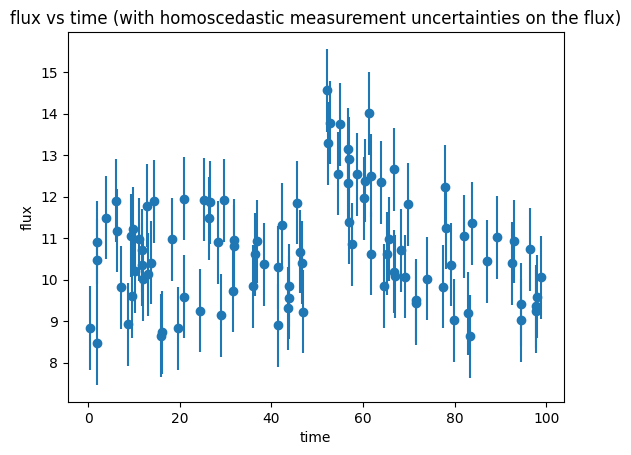

In [2]:
data = np.load('transient.npy')
plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2], fmt="o")
plt.xlabel('time')
plt.ylabel('flux')
plt.title('flux vs time (with homoscedastic measurement uncertainties on the flux)')
plt.show()

One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

In [3]:
t_0 =  50
b = 10
A = 14
alfa = 0.5

init_par = np.array([t_0, b, A, alfa])

In [4]:
def burst(par, t):
    t_0, b, A, alfa = par
    if (t < t_0): return b
    else: return b + A * np.exp(-alfa * (t - t_0))

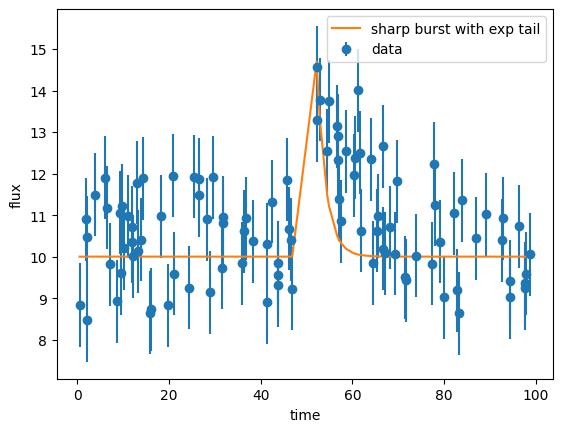

In [5]:
plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2], fmt="o", label = 'data')
y_time =[burst(init_par, d) for d in data [:, 0]]
plt.plot(data[:, 0], y_time, label = 'sharp burst with exp tail')
plt.legend()
plt.xlabel('time')
plt.ylabel('flux')
plt.show()

In [6]:
def log_llh(par, data):
    x, y, sigma_y = data.T
    y_model = [burst(par, xi) for xi in x]
    log_llh = -0.5 * np.sum((y - y_model)**2 / sigma_y ** 2)
    if np.isnan(log_llh): print('found nan in log_llh')
    return log_llh

t_0min, t_0max = 0, 100
bmin, bmax = 0,50
Amin, Amax = 0,50
alphamin, alphamax = np.exp(-5), np.exp(5)

#we have a uniform distribution on A, b, t0 and 1/alpha
#if we take the log prior we have a constant for A, b and t_0 which we put to zero
#and a -log(alpha)
def log_prior (parameters):
    t_0, b, A, alpha = parameters
    if t_0min < t_0 < t_0max and bmin < b < bmax and Amin < A < Amax and alphamin < alpha < alphamax:
        prior =  -np.log(alpha)
    else:        
        prior = -np.inf #we return -inf if one of our parameters ends outside the range we fixed
   
    if np.isnan(prior): print('found nan in log_prior')    
    return prior

def log_posterior(par, data):
    llh = log_llh(par, data)
    prior = log_prior(par)
    result =  llh + prior
    #if llh == np.inf and prior == -np.inf: result = 0
    if np.isnan(result): print('found nan in log_posterior')
    return result

Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).


In [7]:
nparam = 4 
nwalkers = 10 
nsteps = int(1e4) 

#add gaussian samples to our initial guesses
starting_guesses = init_par + 0.1* np.random.randn(nwalkers, nparam)

In [8]:
sampler = emcee.EnsembleSampler(nwalkers, nparam, log_posterior, args=[data])
sampler.run_mcmc(starting_guesses, nsteps)

print('done')

done


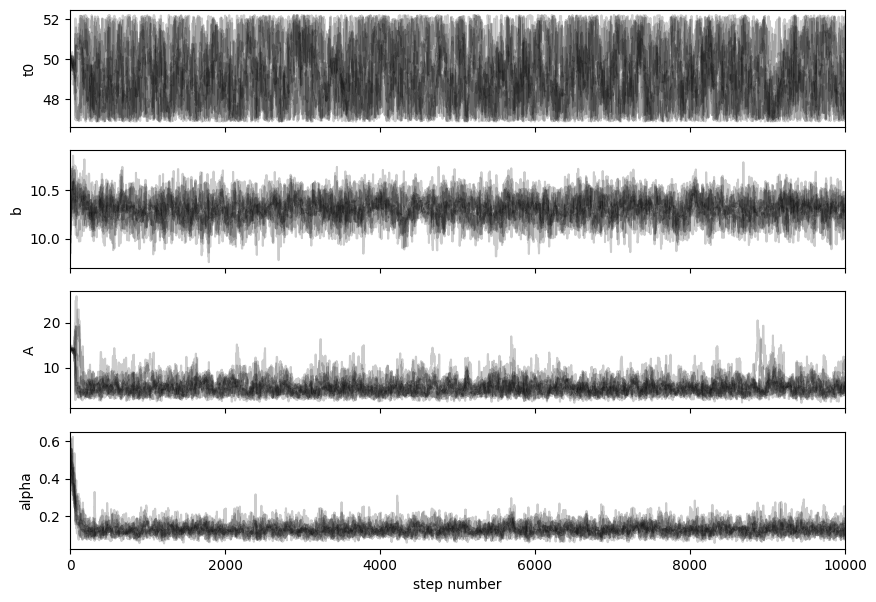

In [9]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["t0","b","A","alpha"]
for i in range(nparam):
    ax = axes[i]
    ax.plot(samples[:, :, i], color = 'black', alpha=0.2)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])

axes[nparam-1].set_xlabel("step number");

In [10]:
import corner

C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (10000) than draws (10). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


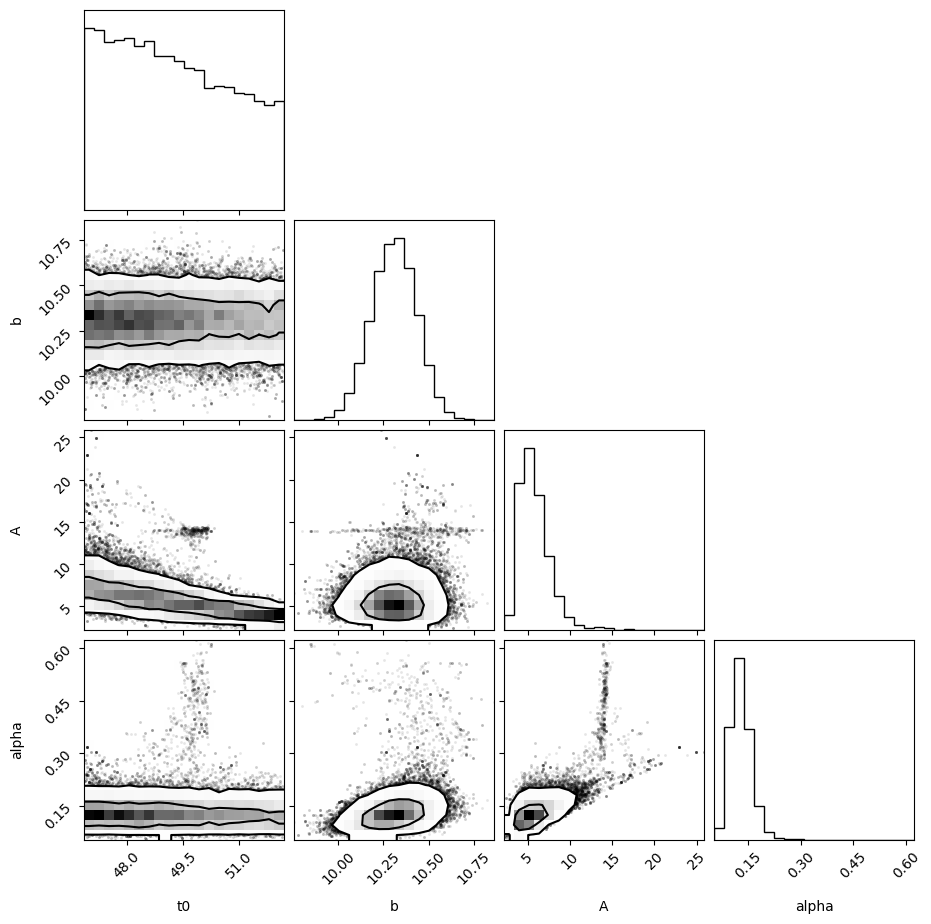

In [11]:
#draw original chain
fig = corner.corner(samples, labels=labels, levels=[0.68,0.95])

If we instead thin out our samples and account for burn-in:

In [12]:
tau = sampler.get_autocorr_time()
print(tau)
thin = int(max(tau))
burn_in = 500

[95.76569482 64.69453278 96.92139917 82.85985869]


In [13]:
flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)


print('\t\t(nsteps, nwalkers, ndim)')
print('shape of original chain: ', samples.shape) 

print('shape of burned + thinned chain:', flat_samples.shape)
#first output is the number of samples left (for each parameter)-> increase nsteps if too low

		(nsteps, nwalkers, ndim)
shape of original chain:  (10000, 10, 4)
shape of burned + thinned chain: (980, 4)


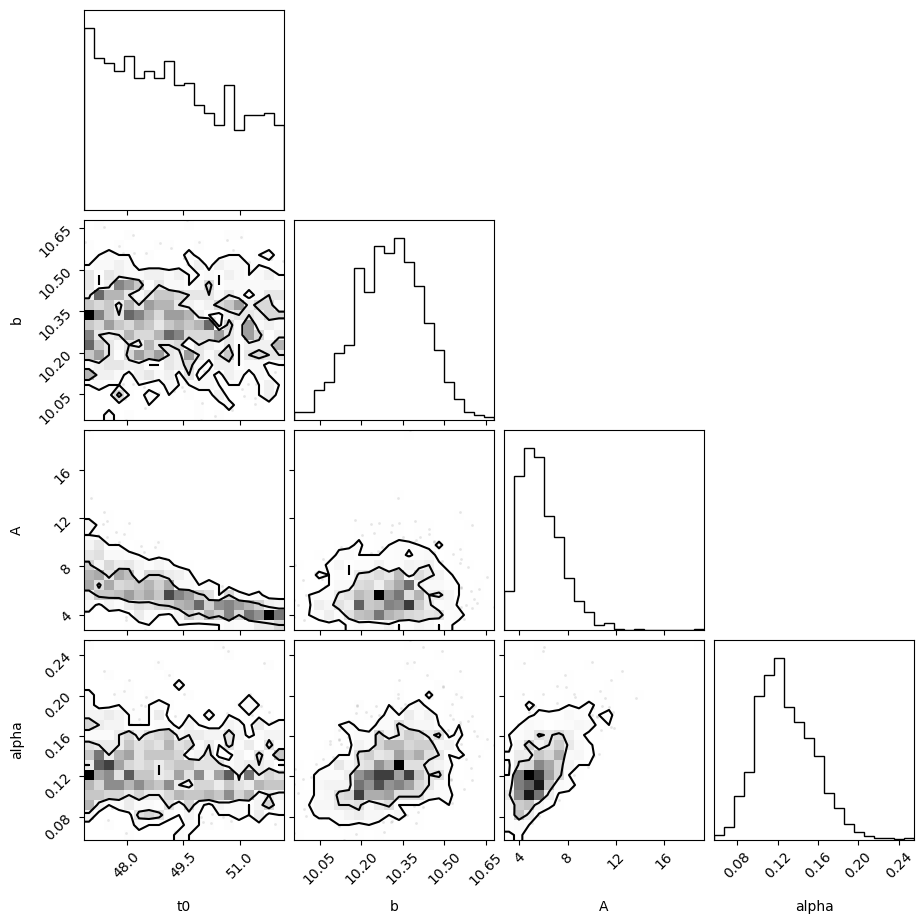

In [14]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95])

Randomly take 100 samples and plot along with data:

In [15]:
idx = np.random.randint(0, flat_samples.shape[0], size = 100)
rand_samples = flat_samples[idx][:]
print(rand_samples.shape)

(100, 4)


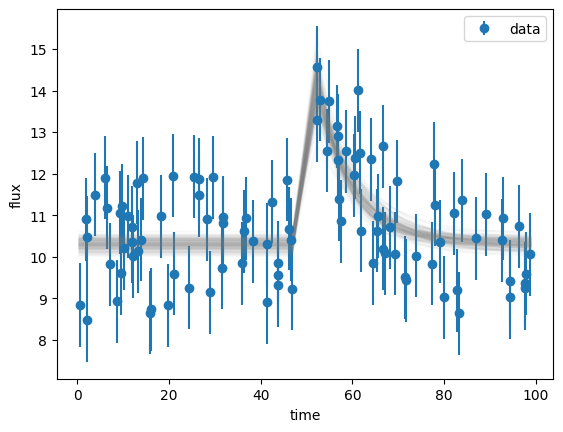

In [16]:
plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2], fmt="o", label = 'data')
for i in range(100):
    y_time =[burst(rand_samples[i][:], d) for d in data [:, 0]]
    plt.plot(data[:, 0], y_time, color = 'gray', alpha = 0.05)
plt.legend()
plt.xlabel('time')
plt.ylabel('flux')
plt.show()

Finally, compute median and 90% credible region of each parameter:

In [17]:
medians = []
lows = []
ups = []
for i in range(nparam):
    medians.append( np.median(flat_samples[:, i]) )
    lows.append( np.percentile(flat_samples[:, i], 5) )
    ups.append( np.percentile(flat_samples[:, i], 95) )
    print(f'{labels[i]}: {medians[i]} - {medians[i] - lows[i]} + {ups[i] - medians[i]}')

t0: 49.072159899674986 - 2.029755669067306 + 2.7138633874365468
b: 10.304713482793195 - 0.20788716077202807 + 0.19199339780031366
A: 5.511763533024901 - 1.871735429672218 + 3.526324160642851
alpha: 0.12370864766463202 - 0.03738410110916139 + 0.05429294713994273


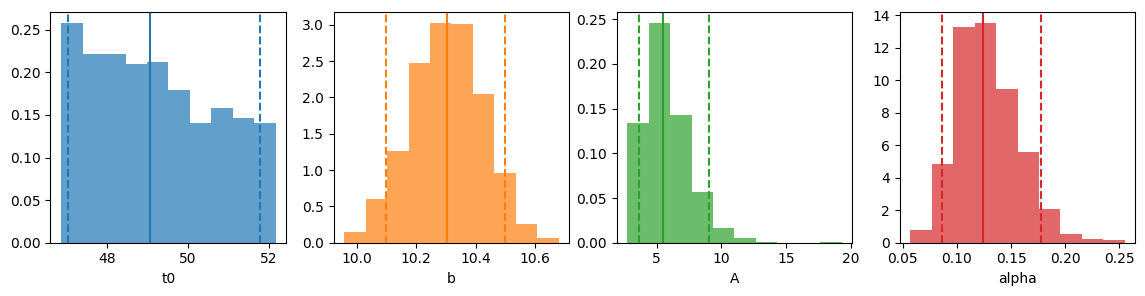

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(14,3))
for i in range(nparam):
    c = 'C'+str(i)
    axes[i].hist(flat_samples[:,i], alpha= 0.7, color = c, density=True)
    axes[i].axvline(medians[i], c=c)
    axes[i].axvline(lows[i], c=c, ls='--')
    axes[i].axvline(ups[i], c=c, ls='--')
    axes[i].set_xlabel(labels[i])

Final plot using the medians:

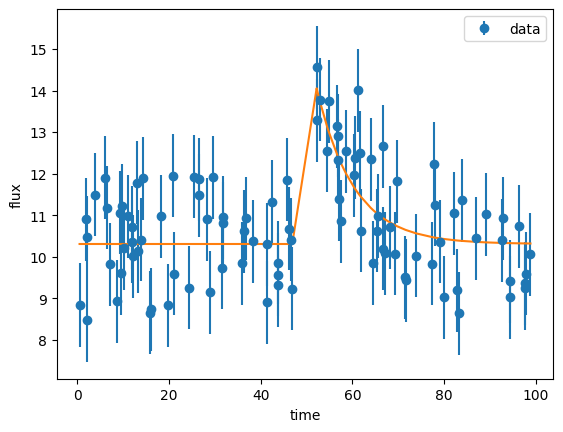

In [23]:
plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2], fmt="o", label = 'data')
y_time =[burst(medians, d) for d in data [:, 0]]
plt.plot(data[:, 0], y_time)
plt.legend()
plt.xlabel('time')
plt.ylabel('flux')
plt.show()